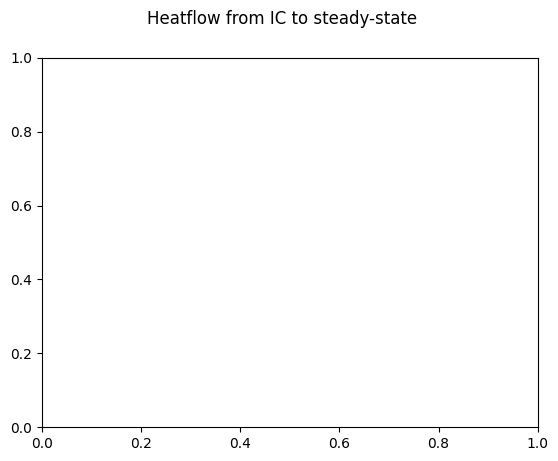

interactive(children=(FloatSlider(value=0.0, description='K', max=3.0, step=0.2), Output()), _dom_classes=('wi…

In [ ]:
from ipywidgets import FloatSlider, IntSlider, interact
%matplotlib widget

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from numpy import sin, exp, pi

L = 1

z = np.linspace(0,  L, 100)
t = np.linspace(0, 0.3, 100)

Z, T = np.meshgrid(z,t)

def soln(K):
    return(
     3*exp(-K*(  pi/2/L)**2*T)*sin(  pi*Z/2/L)
    +5*exp(-K*(3*pi/2/L)**2*T)*sin(3*pi*Z/2/L)
)

fig, ax = plt.subplots(1,1)
plt.suptitle('Heatflow from IC to steady-state')

@interact(
    K = FloatSlider(min=0, max=3, step=0.2)
)
def plot_heat(K):
    ax.clear()
    sns.heatmap(soln(K), ax=ax, xticklabels=False, yticklabels=False, cbar=False)
    ax.set_xlabel('position z ->')
    ax.set_ylabel('<- time t')


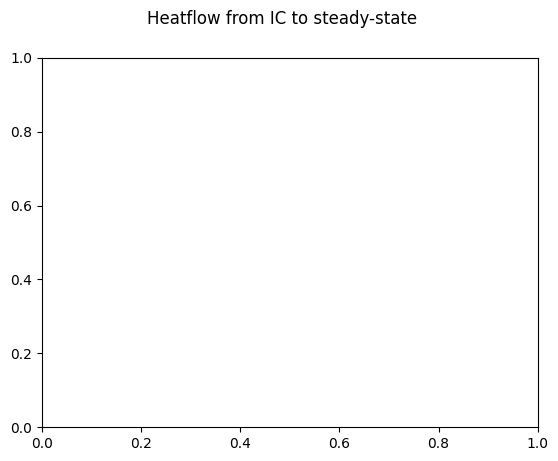

interactive(children=(FloatSlider(value=1.0, description='c', max=3.0, step=0.2), FloatSlider(value=0.0, descr…

In [ ]:
from ipywidgets import FloatSlider, IntSlider, interact
%matplotlib widget

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from numpy import sin, cos, pi

L = 1

x = np.linspace(0, L, 100)
y = np.linspace(0, L, 100)

X, Y = np.meshgrid(z,t)

def soln(c, t):
    return(
         3*sin(  pi*X/L)*sin(2*pi*Y/L)*cos((5 )**(1/2)*c*t*pi/L)
        +4*sin(3*pi*X/L)*sin(5*pi*Y/L)*cos((34)**(1/2)*c*t*pi/L)
)

fig, ax = plt.subplots(1,1)
plt.suptitle('Heatflow from IC to steady-state')

@interact(
    c = FloatSlider(value=1, min=0, max=3, step=0.2),
    t = FloatSlider(value=0, min=0, max=3, step=0.02)
)
def plot_heat(c, t):
    ax.clear()
    sns.heatmap(soln(c, t), ax=ax, 
                xticklabels=False, yticklabels=False, 
                cbar=False, vmin=-7, vmax=7)
    ax.set_xlabel('position z ->')
    ax.set_ylabel('<- time t')

interactive(children=(IntSlider(value=10, description='N', max=500, min=1), IntSlider(value=1, description='A'…

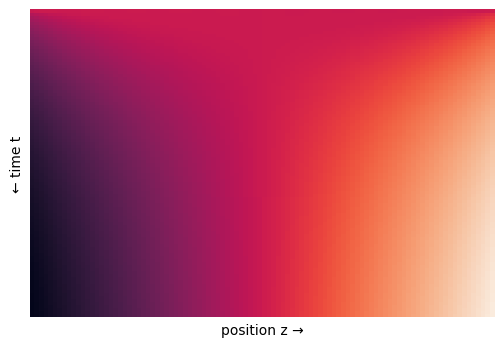

In [28]:
# Chatgpt version

from functools import lru_cache
import numpy as np
from numpy import pi, sin, exp

L = 1
K = 1/4
A = 1
T3= 1

z = np.linspace(0,  L, 100)
t = np.linspace(0, 1, 100)
Z, T = np.meshgrid(z, t)


maxN = 500               # max slider value
n = np.arange(1, maxN+1) # [1,2,...,100]

lambda_n = (n*pi/L)**2
SIN = np.sin((n[:,None] * pi / L) * z[None,:])      # (N, Z)
EXP = np.exp(-K * lambda_n[:,None] * t[None,:])      # (N, T)

# shape (N, T, Z)
BASIS = EXP[:,:,None] * SIN[:,None,:]


def soln(N, Phi):
    """
    Compute u(z,t) using first N odd cosine terms.
    """
    n = np.arange(N)                       # n = 0,...,N-1
    m = 2*n + 1                             # odd mode numbers

    # coefficients: 4 L Phi / (pi^2 (2n+1)^2)
    c_n = 4 * L * Phi / (pi**2 * m**2)      # (N,)

    # exp(-K * ((2n+1)pi/L)^2 * t)
    lambda_m = (m * pi / L)**2              # (N,)
    EXPm = np.exp(-K * lambda_m[:,None] * t[None,:])   # (N, T)

    # cos((2n+1) pi z / L)
    COSm = np.cos((m[:,None] * pi / L) * z[None,:])    # (N, Z)

    # combine into (N,T,Z)
    modes = EXPm[:,:,None] * COSm[:,None,:]

    # sum over n using tensordot
    u_modes = np.tensordot(c_n, modes, axes=(0,0))     # (T,Z)

    # add constant + linear terms
    return (T3 - Phi*L/2) + Phi*Z + u_modes


fig, ax = plt.subplots(figsize=(6,4))
cbar = None

@interact(
    N   = IntSlider(min=1, max=maxN, value=10),
    A   = 1
)
def plot_heat(N, A):    
    global cbar
    ax.clear()

    hm = sns.heatmap(soln(N, A),
                     ax=ax, cbar=False,
                     xticklabels=False, yticklabels=False)

    ax.set_xlabel("position z →")
    ax.set_ylabel("← time t")

    fig.canvas.draw_idle()
    


<Axes: >

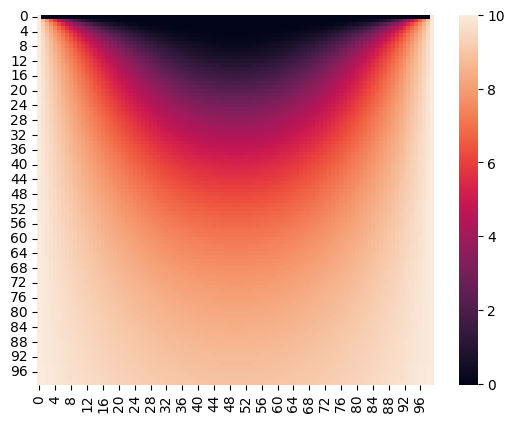

In [29]:
%matplotlib inline
def duz(N, Phi):
    """
    Compute du/dz(z,t) using first N odd sine modes.
    """
    n = np.arange(N)                 # n = 0..N-1
    m = 2*n + 1                      # odd mode numbers

    lambda_m = (m * pi / L)**2       # (N,)
    EXPm = np.exp(-K * lambda_m[:,None] * t[None,:])   # (N,T)

    SINm = np.sin((m[:,None] * pi / L) * z[None,:])    # (N,Z)

    modes = EXPm[:,:,None] * SINm[:,None,:]            # (N,T,Z)

    # coefficient -4 Φ / (π m)
    coeffs = -(4 * Phi / (pi * m))                     # (N,)

    # sum using tensordot
    u_z_modes = np.tensordot(coeffs, modes, axes=(0,0))  # (T,Z)

    # add the derivative of Φ z
    return Phi + u_z_modes



sns.heatmap(duz(1000,10))